In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Exploration: Understanding the Raw Measurements

Before we attempt to mathematically "de-embed" our Device Under Test (DUT) from the test fixtures, we need to understand what our raw data looks like. In RF engineering, measurements are taken using a Vector Network Analyzer (VNA), which outputs **Scattering Parameters (S-parameters)**. 

For a 2-port network, we have four main S-parameters:
* **$S_{11}$ & $S_{22}$ (Reflection):** How much signal bounces back from the input/output.
* **$S_{21}$ & $S_{12}$ (Transmission):** How much signal successfully travels through the device.

Let's load our raw data in to a pandas dataframe, and load the frequencies column for plotting.

In [45]:
df = pd.read_csv("../measurement_data/dut_plus_fixture.csv")
frequencies = df["frequency_Hz"].values

---
# The De-embedding Algorithm: Mathematical Step-by-Step

The `deembedder.py` script performs "mathematical surgery" on RF measurements to isolate the **intrinsic DUT** from the surrounding **fixtures (PADs)**. Paste the entire cell below into a VS Code Markdown file or a Jupyter Markdown cell; LaTeX blocks use `\begin{equation}...\end{equation}` so they render where LaTeX is supported.

---

## 1. Domain Conversion: S to ABCD

S-parameters are convenient for measurement but not for algebraic cancellation of cascaded blocks. Convert S-parameters to ABCD (T) matrices first. For each frequency point compute the ABCD elements:

\begin{equation}
A = \frac{(1 + S_{11})(1 - S_{22}) + S_{12}S_{21}}{2\,S_{21}}
\end{equation}

\begin{equation}
B = Z_{0}\,\frac{(1 + S_{11})(1 + S_{22}) - S_{12}S_{21}}{2\,S_{21}}
\end{equation}

\begin{equation}
C = \frac{1}{Z_{0}}\,\frac{(1 - S_{11})(1 - S_{22}) - S_{12}S_{21}}{2\,S_{21}}
\end{equation}

\begin{equation}
D = \frac{(1 - S_{11})(1 + S_{22}) + S_{12}S_{21}}{2\,S_{21}}
\end{equation}

**Notes**

- Compute these elementwise for every frequency sample.  
- Watch for points where \(S_{21}\) is near zero; add regularization or mask those points before dividing.

---

## 2. Inversion: Build the "Undo" Matrix

If \(T_{\text{Fix}}\) is the ABCD matrix of the fixture (PAD), compute its inverse:

```python
# abcd_fix has shape (N, 2, 2)
abcd_fix_inv = np.linalg.inv(abcd_fix)   # batch inverse per frequency

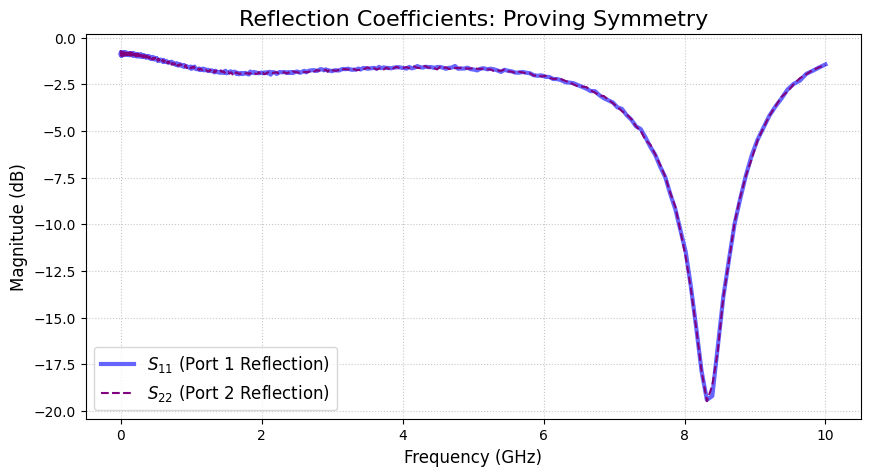

In [46]:
# Calculate S11
s11_mag = np.sqrt(df["S11_real"]**2 + df["S11_imag"]**2)
s11_db = 20 * np.log10(s11_mag + 1e-12)

# Calculate S22
s22_mag = np.sqrt(df["S22_real"]**2 + df["S22_imag"]**2)
s22_db = 20 * np.log10(s22_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s11_db, label="$S_{11}$ (Port 1 Reflection)", color="blue", linewidth=3, alpha=0.6)
plt.plot(frequencies / 1e9, s22_db, label="$S_{22}$ (Port 2 Reflection)", color="purple", linewidth=1.5, linestyle='--')

plt.title("Reflection Coefficients: Proving Symmetry", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 2. Transmission / Insertion Loss ($S_{21}$ & $S_{12}$)

Transmission coefficients measure how much signal successfully travels through the device.
* **$S_{21}$ (Forward):** Signal injected at Port 1, measured at Port 2.
* **$S_{12}$ (Reverse):** Signal injected at Port 2, measured at Port 1.

Because passive components do not amplify signals and do not have directional dependencies, they are **reciprocal**. This means $S_{21}$ must equal $S_{12}$. Let's plot them to confirm our setup is reciprocal.

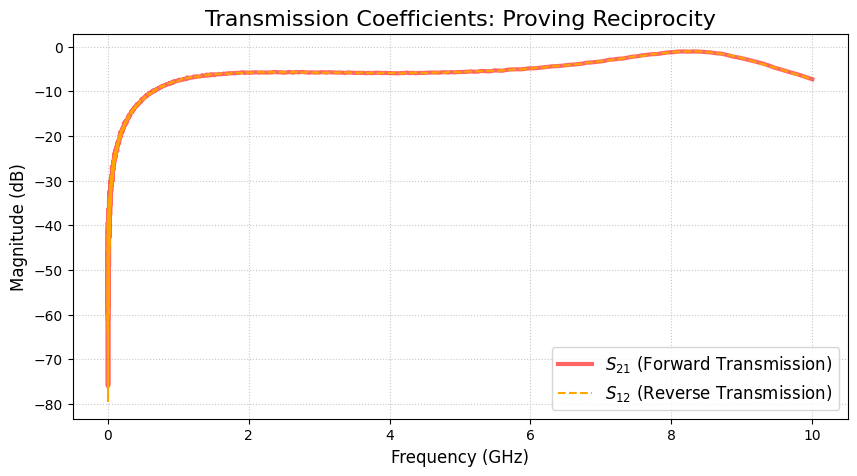

In [47]:
# Изчисляваме S21
s21_mag = np.sqrt(df["S21_real"]**2 + df["S21_imag"]**2)
s21_db = 20 * np.log10(s21_mag + 1e-12)

# Изчисляваме S12
s12_mag = np.sqrt(df["S12_real"]**2 + df["S12_imag"]**2)
s12_db = 20 * np.log10(s12_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s21_db, label="$S_{21}$ (Forward Transmission)", color="red", linewidth=3, alpha=0.6)
plt.plot(frequencies / 1e9, s12_db, label="$S_{12}$ (Reverse Transmission)", color="orange", linewidth=1.5, linestyle='--')

plt.title("Transmission Coefficients: Proving Reciprocity", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Impact of Measurement Fixtures on RF Transmission

The plot below compares the **ideal transmission response of the DUT** with the **raw measurement obtained through fixtures**.  
The transmission parameter being analyzed is **S₂₁**, which describes how much of the input signal at Port 1 is transmitted to Port 2.

In RF systems:

- **|S₂₁| ≈ 1 (0 dB)** means nearly all power is transmitted.
- **|S₂₁| < 1 (negative dB)** indicates losses in the system.

The green curve represents the **Golden DUT response**, which corresponds to the intrinsic behavior of the device without any measurement artifacts.

The red curve represents the **raw measurement**, which includes:

- fixture parasitics
- impedance mismatch
- measurement noise

Several important effects can be observed in the current setup:

1. **Passband Transmission & Fixture Offset**
    Away from resonance, the ideal DUT allows full transmission (0 dB). The raw measurement (red curve) stays several dB below this, representing the **broadband loss and mismatch** from the PADs.

2. **Fixture-Induced Notch Distortion**
    The resonant notch at 5.03 GHz is clearly visible, but in the raw data, it is **shallower and broader**. The fixture parasitics "mask" the true rejection depth of the intrinsic RLC branch.

3. **High-Frequency Parasitic Roll-off**
    While the ideal DUT recovers to 0 dB after resonance, the raw measurement shows a continuous downward tilt. This is caused by the **shunt parasitic capacitance** of the fixtures draining the signal to ground at higher frequencies.

4. **Noise Floor Collision**
    At frequencies above 9 GHz, the raw signal becomes so weak that it hits the **measurement noise floor**. This is visible as jagged, random artifacts where the signal is no longer distinguishable from system noise.

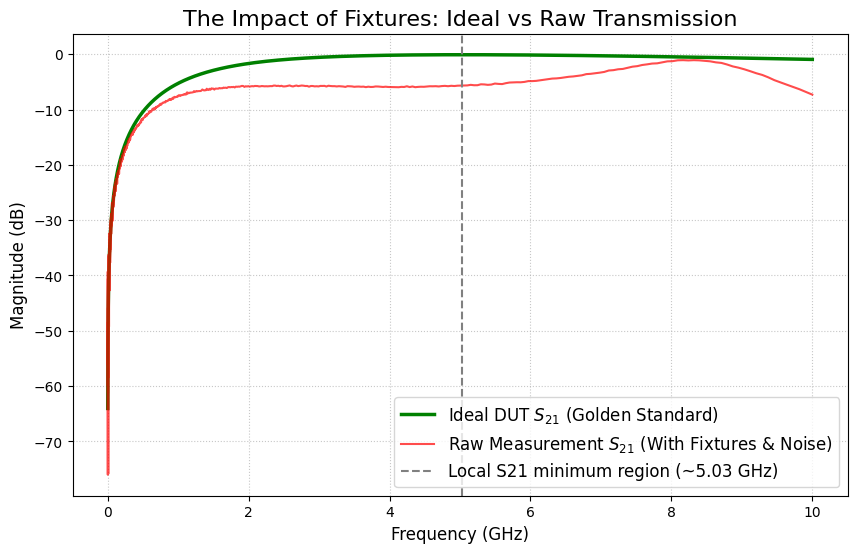

In [48]:
# Load the ideal data for comparison
df_golden = pd.read_csv("../measurement_data/golden_dut.csv")

# Calculate Golden S21 in dB
s21_gold_mag = np.sqrt(df_golden["S21_real"]**2 + df_golden["S21_imag"]**2)
s21_gold_db = 20 * np.log10(s21_gold_mag + 1e-12)

plt.figure(figsize=(10, 6))
plt.plot(frequencies / 1e9, s21_gold_db, label="Ideal DUT $S_{21}$ (Golden Standard)", color="green", linewidth=2.5)
plt.plot(frequencies / 1e9, s21_db, label="Raw Measurement $S_{21}$ (With Fixtures & Noise)", color="red", alpha=0.7)

plt.title("The Impact of Fixtures: Ideal vs Raw Transmission", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)

plt.axvline(x=5.03, color='gray', linestyle='--', label='Local S21 minimum region (~5.03 GHz)')

plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Summary of Measured System Characteristics (Shunt Topology)

---

## 1. Fundamental Network Properties

* **Passivity & Reciprocity:** The perfect overlap of $S_{21}$ and $S_{12}$ confirms that the system is a **passive reciprocal network**.
* **Port Symmetry:** The overlap of $S_{11}$ and $S_{22}$ confirms that the input and output fixtures (PADs) are **identical (port-symmetric)**.

---

## 2. Device Under Test (DUT): The Notch Filter

* **Topology:** The DUT is a shunt-connected series RLC branch, with the following parameters, encoded in the generator: 
    dut_params={'r': 1.0, 'l': 1e-9, 'c': 6e-12},
* **Theoretical Resonance:**
    $$f_0 = \frac{1}{2\pi\sqrt{LC}} \approx 5.03 \text{ GHz}$$
* **Physical Behavior:** At resonance, the impedance drops to $Z \approx R = 1 \Omega$. Since the branch is connected in parallel (shunt) to ground, it acts as an **RF Short**. This creates the observed **Transmission Null (Notch)** with maximum signal rejection.

---

## 3. Impact of Fixtures (PADs)

* **Parasitic Loading:** Fixture PADs ($R=1000 \Omega, C=1 \text{ pF}$) act as shunt low-pass elements, causing the baseline transmission to tilt downwards at high frequencies.
* **Response Distortion:** The interaction between the DUT’s inductance and the fixtures' parasitic capacitance modifies the composite matching, shifting the "ideal" resonant response.
* **Signal Loss:** The fixtures reduce the notch depth and mask the pure RLC signature across the frequency sweep, leading to the "raw" distorted measurement.